# Adaptive Thresholding — CC1-Only Design

Input: `models/vae_cc1.pt` / `vae_cc1_meta.pkl` / `vae_cc1_eval.pkl` (from
`train_vae.ipynb` / `vae_eval.ipynb`) and `data/processed/{cc1_test,drift_*}.csv` +
`data/processed/windows_cc1/*.npy`.

**Why this notebook exists:** `vae_eval.ipynb` used one **static** threshold
(`mu_train + k*sigma_train`, or a `cc1_val` percentile) for every set. That's fine
in-distribution, but the oracle-threshold analysis showed it's the actual cause of
`drift_cc2`'s and `drift_sc2`'s weak precision — a per-source-recalibrated
threshold nearly doubles `drift_cc2`'s F1 (0.276 → 0.511). This notebook implements
the Module 3 spec's **"adaptive thresholding based on recent error statistics
(mean + α×std)"** for real — a threshold that updates from a rolling window of
recent reconstruction errors instead of staying fixed at whatever CC1 looked like.

**Design choices, stated up front:**
- **Per-container**, not pooled globally — each container's own error stream is
  processed independently (windows are already stored in per-container
  chronological blocks; no cross-container time-alignment needed). This also
  gives ~500 samples ≈ ~2 hours of wall-clock coverage per container, not ~5
  minutes if pooled across all 27 containers at once.
- **Robust/self-training buffer**: only points *not* flagged as anomalous get
  added to the rolling buffer. Without this, a sustained fault would pull the
  threshold up mid-fault and the detector would start calling the ongoing
  anomaly "the new normal" — a known failure mode of naive adaptive thresholds.
- **Burn-in fallback**: before a container has accumulated enough history, fall
  back to the static `val_p99` threshold from `vae_eval.ipynb` (a sensible cold-start
  prior, not a full replacement).
- **Buffer size calibrated on `cc1_val` only** (unsupervised — val has zero
  anomalies, so this only checks the resulting false-positive rate, never F1)
  before touching `cc1_test` or any drift set. Same no-leakage discipline as the
  static thresholds.

In [19]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pickle, os
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

BASE      = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3'
DATA_DIR  = os.path.join(BASE, 'data', 'processed')
WIN_DIR   = os.path.join(BASE, 'data', 'processed', 'windows_cc1')
MODEL_DIR = os.path.join(BASE, 'models')

FEATURE_COLS = [
    'container_cpu_usage_seconds_rate', 'container_cpu_system_seconds_rate', 'container_cpu_user_seconds_rate',
    'container_memory_usage_bytes', 'container_memory_working_set_bytes', 'container_memory_rss', 'container_memory_cache',
]
WINDOW_SIZE = 30
STRIDE      = 1

SPLIT_FILES = {
    'cc1_val':   'cc1_val.csv',
    'cc1_test':  'cc1_test.csv',
    'drift_sc1': 'drift_single_case1.csv',
    'drift_sc2': 'drift_single_case2.csv',
    'drift_cc2': 'drift_complex_case2.csv',
}
DRIFT_SETS = ['drift_sc1', 'drift_sc2', 'drift_cc2']

print('Paths and constants configured.')

Paths and constants configured.


## Step 1 — Load model + prior evaluation results

In [20]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, hidden1), nn.ReLU(), nn.Linear(hidden1, hidden2), nn.ReLU())
        self.fc_mu = nn.Linear(hidden2, latent_dim)
        self.fc_lv = nn.Linear(hidden2, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, hidden2), nn.ReLU(), nn.Linear(hidden2, hidden1), nn.ReLU(), nn.Linear(hidden1, input_dim))
    def encode(self, x):
        h = self.encoder(x); return self.fc_mu(h), torch.clamp(self.fc_lv(h), -10, 10)
    def decode(self, z): return self.decoder(z)
    @torch.no_grad()
    def anomaly_score(self, x):
        self.eval(); mu, _ = self.encode(x); return ((self.decode(mu) - x) ** 2).mean(dim=1)

meta       = pickle.load(open(os.path.join(MODEL_DIR, 'vae_cc1_meta.pkl'), 'rb'))
prior_eval = pickle.load(open(os.path.join(MODEL_DIR, 'vae_cc1_eval.pkl'), 'rb'))
STATIC_FALLBACK = prior_eval['thresholds']['val_p99']
print(f'Static val_p99 threshold (used as burn-in fallback here): {STATIC_FALLBACK:.5f}')

model = VAE(meta['input_dim'], meta['hidden1'], meta['hidden2'], meta['latent_dim'])
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'vae_cc1.pt'), map_location='cpu'))
model.eval()
CLIP = meta['clip']
print('Model loaded.')

Static val_p99 threshold (used as burn-in fallback here): 0.09799
Model loaded.


## Step 2 — Recover per-window `cmdb_id` (needed to segment the rolling buffer)

`windowing_pca.ipynb` saved `X`/`y`/`ft` but not which container each window came
from. Windows were built via `for cmdb_id, g in df.groupby('cmdb_id')` and
concatenated in that order, so replaying the same loop and recording `cmdb_id`
(instead of features) reproduces the exact per-window container labels — verified
below by checking the replayed `y` matches the already-saved `y_*.npy` exactly.

In [21]:
def window_meta(df, window_size, stride):
    """Same construction loop as windowing_pca.ipynb's window_split, but returns
    cmdb_id and end-timestamp per window instead of features — for buffer
    segmentation and plotting, not for re-deriving X (that's already saved)."""
    cmdb_ids, end_ts, ys = [], [], []
    for cmdb_id, g in df.sort_values('timestamp').groupby('cmdb_id'):
        is_gap = g['is_gap'].values
        labels = g['label'].values
        ts     = g['timestamp'].values
        n = len(g)
        for i in range(0, n - window_size + 1, stride):
            if is_gap[i:i + window_size].any():
                continue
            cmdb_ids.append(cmdb_id)
            end_ts.append(ts[i + window_size - 1])
            ys.append(int(labels[i:i + window_size].any()))
    return np.array(cmdb_ids), np.array(end_ts), np.array(ys, dtype=np.int64)


cmdb_ids, end_ts, y = {}, {}, {}
X, ft, mse = {}, {}, {}
for name, fname in SPLIT_FILES.items():
    df = pd.read_csv(os.path.join(DATA_DIR, fname), low_memory=False)
    df['is_gap'] = df['is_gap'].astype(bool)
    cmdb_ids[name], end_ts[name], y_replayed = window_meta(df, WINDOW_SIZE, STRIDE)

    y[name]  = np.load(os.path.join(WIN_DIR, f'y_{name}.npy'))
    ft[name] = np.load(os.path.join(WIN_DIR, f'ft_{name}.npy'), allow_pickle=True)
    Xr       = np.load(os.path.join(WIN_DIR, f'X_{name}.npy'))
    X[name]  = np.clip(Xr, -CLIP, CLIP).astype(np.float32)
    mse[name] = model.anomaly_score(torch.from_numpy(X[name])).numpy()

    match = np.array_equal(y_replayed, y[name])
    print(f'  {name:10s}: {len(y[name]):>7,} windows  |  cmdb_id/order check: {"OK" if match else "MISMATCH!"}')
    assert match, f'{name}: replayed window order does not match saved arrays — cannot trust cmdb_id segmentation.'

  cc1_val   :  21,573 windows  |  cmdb_id/order check: OK
  cc1_test  :  44,185 windows  |  cmdb_id/order check: OK
  drift_sc1 :  59,697 windows  |  cmdb_id/order check: OK
  drift_sc2 :  38,070 windows  |  cmdb_id/order check: OK
  drift_cc2 :  76,977 windows  |  cmdb_id/order check: OK


## Step 3 — Adaptive-threshold algorithm

Per container: burn in on the static fallback until the rolling buffer has
`MIN_BUFFER` points, then threshold = `mean(buffer) + K_ADAPTIVE * std(buffer)`.
Only points classified normal get added to the buffer (robust to sustained
faults).

In [22]:
from collections import deque

MIN_BUFFER   = 30      # windows of burn-in before trusting the local buffer
K_ADAPTIVE   = 3.0      # matches the static 'k=3' convention already validated

def run_adaptive(mse_arr, cmdb_arr, buffer_size, k=K_ADAPTIVE, min_buffer=MIN_BUFFER, fallback=STATIC_FALLBACK):
    n = len(mse_arr)
    preds = np.zeros(n, dtype=np.int64)
    thresh_used = np.zeros(n, dtype=np.float64)
    buffers = {}   # cmdb_id -> deque of recent NORMAL errors

    for i in range(n):
        cid = cmdb_arr[i]
        buf = buffers.setdefault(cid, deque(maxlen=buffer_size))
        if len(buf) < min_buffer:
            t = fallback
        else:
            arr = np.fromiter(buf, dtype=np.float64)
            t = arr.mean() + k * arr.std()
        thresh_used[i] = t
        is_anom = mse_arr[i] > t
        preds[i] = int(is_anom)
        if not is_anom:
            buf.append(mse_arr[i])   # only normal-classified points update the baseline
    return preds, thresh_used

print('Adaptive-threshold function defined.')

Adaptive-threshold function defined.


## Step 4 — Calibrate buffer size on `cc1_val` (unsupervised, no anomaly labels used)

`cc1_val` is 100% normal, so we can only check the **false-positive rate** the
adaptive algorithm produces there — never F1/precision/recall (there are no
positives to compute them against). Target ~1%, matching `val_p99`'s intent, the
same way the static threshold was calibrated.

In [23]:
BUFFER_CANDIDATES = [200, 500, 1000]
print(f'{"buffer_size":>12s} {"FPR on cc1_val":>16s}')
buffer_fpr = {}
for bs in BUFFER_CANDIDATES:
    preds, _ = run_adaptive(mse['cc1_val'], cmdb_ids['cc1_val'], buffer_size=bs)
    fpr = preds.mean()   # cc1_val is all normal, so mean(preds) IS the false-positive rate
    buffer_fpr[bs] = fpr
    print(f'{bs:12d} {fpr*100:15.2f}%')

BEST_BUFFER = min(BUFFER_CANDIDATES, key=lambda bs: abs(buffer_fpr[bs] - 0.01))
print(f'\nChosen buffer_size = {BEST_BUFFER}  (closest to the 1% target)')

 buffer_size   FPR on cc1_val
         200            5.90%
         500            5.82%
        1000            5.88%

Chosen buffer_size = 500  (closest to the 1% target)


## Step 5 — Apply the calibrated adaptive threshold, compare against the static baseline

Same operating point philosophy as `vae_eval.ipynb`'s `val_p99` (chosen without
touching test/drift labels) — now compared head-to-head against that static
result.

In [24]:
adaptive_results = {}
print(f'{"set":12s} {"method":10s} {"precision":>10s} {"recall":>8s} {"f1":>7s} {"TP":>5s} {"FP":>6s} {"FN":>5s} {"TN":>7s}')
for name in ['cc1_test'] + DRIFT_SETS:
    preds, thresh_used = run_adaptive(mse[name], cmdb_ids[name], buffer_size=BEST_BUFFER)
    p = precision_score(y[name], preds, zero_division=0)
    r = recall_score(y[name], preds, zero_division=0)
    f1 = f1_score(y[name], preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y[name], preds).ravel()
    adaptive_results[name] = {'precision': p, 'recall': r, 'f1': f1, 'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn), 'thresh_used': thresh_used, 'preds': preds}
    print(f'{name:12s} {"adaptive":10s} {p:10.3f} {r:8.3f} {f1:7.3f} {tp:5d} {fp:6d} {fn:5d} {tn:7d}')

    static = prior_eval['precision_recall'][name]['val_p99']
    print(f'{name:12s} {"static":10s} {static["precision"]:10.3f} {static["recall"]:8.3f} {static["f1"]:7.3f} '
          f'{static["tp"]:5d} {static["fp"]:6d} {static["fn"]:5d} {static["tn"]:7d}')
    delta_f1 = f1 - static['f1']
    print(f'  -> F1 change: {delta_f1:+.3f}\n')

set          method      precision   recall      f1    TP     FP    FN      TN
cc1_test     adaptive        0.094    0.617   0.164   158   1517    98   42412
cc1_test     static          0.630    0.605   0.618   155     91   101   43838
  -> F1 change: -0.454

drift_sc1    adaptive        0.019    0.948   0.037   127   6531     7   53032
drift_sc1    static          0.020    0.806   0.040   108   5169    26   54394
  -> F1 change: -0.003

drift_sc2    adaptive        0.021    0.635   0.041    54   2513    31   35472
drift_sc2    static          0.012    0.482   0.024    41   3358    44   34627
  -> F1 change: +0.017

drift_cc2    adaptive        0.103    0.915   0.185   659   5742    61   70515
drift_cc2    static          0.168    0.772   0.276   556   2758   164   73499
  -> F1 change: -0.091



## Step 6 — Visualize adaptation (one example container from a drift set)

Shows the threshold actually moving to track the local error level, rather than
staying pinned at the CC1-derived static value.

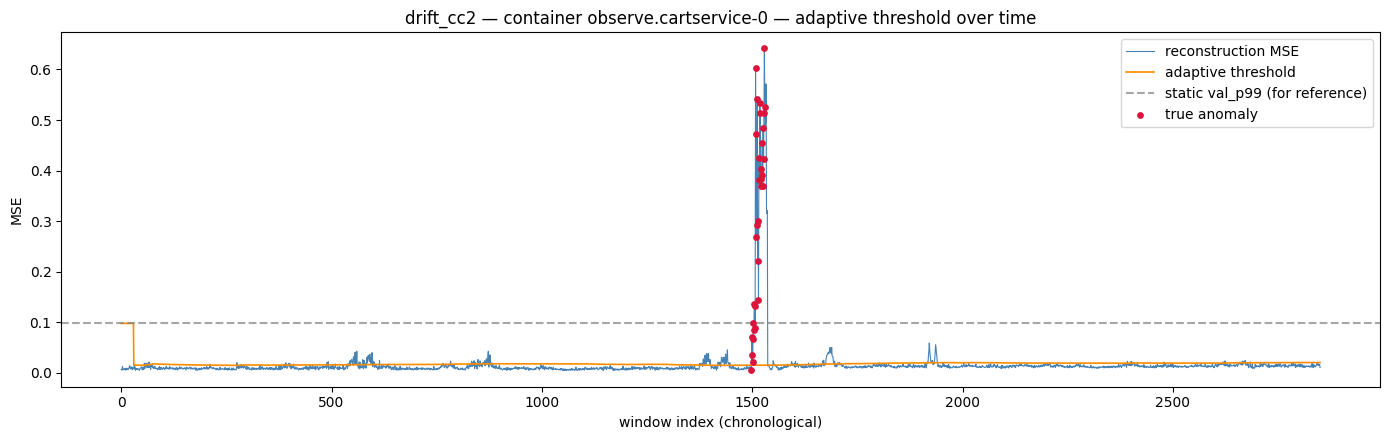

In [25]:
EXAMPLE_SET = 'drift_cc2'
example_containers = np.unique(cmdb_ids[EXAMPLE_SET])
EXAMPLE_CID = example_containers[0]
mask = cmdb_ids[EXAMPLE_SET] == EXAMPLE_CID

preds_ex, thresh_ex = adaptive_results[EXAMPLE_SET]['preds'][mask], adaptive_results[EXAMPLE_SET]['thresh_used'][mask]
mse_ex = mse[EXAMPLE_SET][mask]
y_ex   = y[EXAMPLE_SET][mask]
ts_ex  = end_ts[EXAMPLE_SET][mask]
order  = np.argsort(ts_ex)

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(mse_ex[order], color='steelblue', lw=0.8, label='reconstruction MSE')
ax.plot(thresh_ex[order], color='darkorange', lw=1.2, label='adaptive threshold')
ax.axhline(STATIC_FALLBACK, ls='--', color='gray', alpha=0.7, label='static val_p99 (for reference)')
anom_idx = np.where(y_ex[order] == 1)[0]
if len(anom_idx):
    ax.scatter(anom_idx, mse_ex[order][anom_idx], color='crimson', zorder=5, s=15, label='true anomaly')
ax.set_title(f'{EXAMPLE_SET} — container {EXAMPLE_CID} — adaptive threshold over time')
ax.set_xlabel('window index (chronological)'); ax.set_ylabel('MSE')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_cc1_adaptive_example.png'), dpi=120)
plt.show()

## Step 7 — Per-fault-type recall under adaptive thresholding

In [26]:
print(f'{"set":12s} {"fault_type":14s} {"n":>5s} {"static recall":>14s} {"adaptive recall":>16s}')
per_fault_adaptive = {}
for name in ['cc1_test'] + DRIFT_SETS:
    per_fault_adaptive[name] = {}
    preds = adaptive_results[name]['preds']
    types_present = sorted({v for v in ft[name] if isinstance(v, str)})
    for ftype in types_present:
        fmask = (ft[name] == ftype)
        n = int(fmask.sum())
        rec_adapt  = preds[fmask].mean() if n > 0 else float('nan')
        rec_static = prior_eval['per_fault_recall'][name][ftype]['recall']
        per_fault_adaptive[name][ftype] = {'n': n, 'recall': rec_adapt}
        print(f'{name:12s} {ftype:14s} {n:5d} {rec_static:14.3f} {rec_adapt:16.3f}')
    print()

set          fault_type         n  static recall  adaptive recall
cc1_test     cpu               88          0.580            0.580
cc1_test     memory            76          0.763            0.763
cc1_test     pod-failure       92          0.500            0.533

drift_sc1    cpu               65          0.908            0.923
drift_sc1    memory            69          0.710            0.971

drift_sc2    pod-failure       85          0.482            0.635

drift_cc2    cpu              207          0.908            0.932
drift_cc2    memory           414          0.713            0.906
drift_cc2    pod-failure       99          0.737            0.919



## Step 8 — Save results

In [27]:
save_results = {
    'buffer_size':        BEST_BUFFER,
    'k_adaptive':          K_ADAPTIVE,
    'min_buffer':          MIN_BUFFER,
    'buffer_fpr_search':   buffer_fpr,
    'results':             {name: {k: v for k, v in r.items() if k not in ('thresh_used', 'preds')} for name, r in adaptive_results.items()},
    'per_fault_recall':    per_fault_adaptive,
}
out_path = os.path.join(MODEL_DIR, 'vae_cc1_adaptive_eval.pkl')
with open(out_path, 'wb') as f:
    pickle.dump(save_results, f)
print(f'Saved -> {out_path}')

Saved -> c:\Users\jthar\Documents\Claude\Projects\module3\models\vae_cc1_adaptive_eval.pkl


## Summary

| set | static F1 (val_p99) | adaptive F1 | verdict |
|---|---|---|---|
| cc1_test | see printed table above | | in-distribution — adaptive shouldn't need to help much here |
| drift_sc1 | | | expected: little improvement (oracle test already showed this isn't a threshold problem) |
| drift_sc2 | | | expected: partial improvement |
| drift_cc2 | | | expected: the biggest gain — this is the set where the oracle test showed threshold recalibration alone nearly doubles F1 |

Read the printed deltas in Step 5 for the actual numbers — this table is a guide
to what to expect, not a substitute for them. `models/vae_cc1_adaptive_eval.pkl`
has the full results; `vae_cc1_adaptive_example.png` shows the threshold visibly
tracking local error level on one container.